In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
from scipy.linalg import expm
 
# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

# Intro

Hamiltonian:

$H=-h(X_1+X_2)-J Z_1 Z_2$

Trotter formula:

$e^{-iH t}=(e^{i h X_1 \Delta t}e^{i h X_2 \Delta t}e^{i J Z_1 Z_2 \Delta t})^{N_{\text{Trot}}},$

where $\Delta t=t/N_{\text{Trot}}$.

In [3]:
def tfimCircuitWithNoiseAtEnd(qc, i_start, i_end, J, h, t, N_Trot, Lambda):
    # Time increment for each Trotter step
    dt = t / N_Trot
    
    # Create a new quantum circuit
    
    # Define the depolarizing error
    depolarizing = depolarizing_error(Lambda, 1)
    two_qubit_depolarizing = depolarizing_error(Lambda, 2)
    
    for step in range(N_Trot):
        # Apply the ZZ coupling terms with noise
        for i in range(i_start,i_end):
            qc.rzz(2 * J * dt, i, i + 1)
        
        # Apply the transverse field terms with noise
        for i in range(i_start,i_end+1):
            qc.rx(2 * h * dt, i)
    qc.append(two_qubit_depolarizing, [i_start, i_end])
    
    return qc

def tfimCircuitWithGateNoise(qc, i_start, i_end, J, h, t, N_Trot, epsilon):
    # Time increment for each Trotter step
    dt = t / N_Trot
    
    # Create a new quantum circuit
    
    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    
    for step in range(N_Trot):
        # Apply the ZZ coupling terms with noise
        for i in range(i_start,i_end):
            qc.rzz(2 * J * dt, i, i + 1)
            qc.append(two_qubit_depolarizing, [i, i+1])
        
        # Apply the transverse field terms with noise
        for i in range(i_start,i_end+1):
            qc.rx(2 * h * dt, i)
            qc.append(depolarizing, [i])
    
    return qc

def construct_hamiltonian(N, J, h):
    
    #definitions
    sigma_x = np.array([[0, 1], [1, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    identity = np.eye(2)
    
    H = np.zeros((2**N, 2**N))
    
    # Interaction term: +J * sum(sigma_z[i] * sigma_z[i+1])
    for i in range(N):
        for j in range(i+1, N):
            term = 1
            for k in range(N):
                if k == i:
                    term = np.kron(term, sigma_z)
                elif k == j:
                    term = np.kron(term, sigma_z)
                else:
                    term = np.kron(term, identity)
            H += J * term

    # Transverse field term: +h * sum(sigma_x[i])
    for i in range(N):
        term = 1
        for j in range(N):
            if j == i:
                term = np.kron(term, sigma_x)
            else:
                term = np.kron(term, identity)
        H += h * term

    return H

## Function defs

In [4]:
def getExactState(J, h, time):
    hamiltonian = construct_hamiltonian(2, J, h)

    # Exact time evolution using matrix exponentiation
    exact_operator = expm(-1j * time * hamiltonian)
    
    # Create an initial state (|00...0>)
    initial_state = np.zeros(2**2)
    initial_state[0] = 1
    
    # Apply exact time evolution
    pure_state = exact_operator @ initial_state
    pure_state = DensityMatrix(pure_state)

    return pure_state

In [5]:
def getInputRho(noise, J, h, t, N_trot, gate_noise=0):
# Input state without purification, used for benchmarking     
    # Create a Quantum Circuit acting on a quantum register of 2 qubits
    qc = QuantumCircuit(2)

    if gate_noise==0:
        qc=tfimCircuitWithNoiseAtEnd(qc, 0, 1, J, h, t, N_trot, noise)
    else:
        qc=tfimCircuitWithGateNoise(qc, 0, 1, J, h, t, N_trot, noise)
        
    state = DensityMatrix(qc)

    return state

In [6]:
def getRhoPrimeWithSWAPTest(Lambda, gate_noise=0):
    J=1
    h=1 
    t=1
    N_Trot=10
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(5)

    qc=tfimCircuitWithNoiseAtEnd(qc, 1, 2, J, h, t, N_Trot, Lambda)
    qc=tfimCircuitWithNoiseAtEnd(qc, 3, 4, J, h, t, N_Trot, Lambda)
        
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 1, 3)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(0, 2, 4)
    
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    
    state = DensityMatrix(qc)

    state = DensityMatrix(qc)

    # Trace out all qubits except q0 to get the reduced density matrix for q0
    # output_rho _q0 = partial_trace(state, [1, 2, 3, 4])
    
    # # Extract probabilities from the reduced density matrix of q0
    # prob_0 = output_rho _q0.data[0, 0].real  # Probability of q0 being in |0>
    # prob_1 = output_rho _q0.data[1, 1].real  # Probability of q0 being in |1>

    # Create the 5-qubit projection operator using tensor products

      # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0))
    projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1))


    #outcome0
    rho_outcome_0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    normalized_rho_outcome_0=rho_outcome_0/prob_0

    #outcome1
    rho_outcome_1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    normalized_rho_outcome_1=rho_outcome_1/prob_1

    # Trace out qubits q0, q3, and q4
    output_rho0 = partial_trace(DensityMatrix(normalized_rho_outcome_0), [0, 1, 2])
    output_rho1 = partial_trace(DensityMatrix(normalized_rho_outcome_1), [0, 1, 2])

    purified_rho=prob_0*output_rho0  + prob_1*output_rho1 #for both outcomes, trace out one reg, therefore the overall state should be as if the purification is not done

    return purified_rho

In [7]:
def getRhoPrimeWithSWAPNET(Lambda,N_trials,post_select=0):
    J=1
    h=1 
    t=1
    N_Trot=10
    list_rho_odd=[]
    list_rho_even=[]
    list_p0_odd=[]
    list_p0_even=[]
    list_p1_odd=[]
    list_p1_even=[]

    qc_odd = QuantumCircuit(7)
    qc_odd.reset(0)
    # Apply the Hadamard gate to the first qubit
    qc_odd.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_odd.cswap(0, 1, 3)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_odd.cswap(0, 2, 4)
    
    # Apply the second Hadamard gate to the first qubit
    qc_odd.h(0)

    
    qc_even = QuantumCircuit(7)
    qc_even.reset(0)
    # Apply the Hadamard gate to the first qubit
    qc_even.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_even.cswap(0, 1, 5)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_even.cswap(0, 2, 6)
    
    # Apply the second Hadamard gate to the first qubit
    qc_even.h(0)


    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(7)
    
    qc=tfimCircuitWithNoiseAtEnd(qc, 1, 2, J, h, t, N_Trot, Lambda)
    qc=tfimCircuitWithNoiseAtEnd(qc, 3, 4, J, h, t, N_Trot, Lambda)
    qc=tfimCircuitWithNoiseAtEnd(qc, 5, 6, J, h, t, N_Trot, Lambda)
    
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 1, 3)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(0, 2, 4)
    
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    
    state = DensityMatrix(qc)


    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    
    # Create the 7-qubit projection operator using tensor products
    projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0))
    projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1))
    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    # print(post_meas_rho0)
    list_p0_odd.append(prob_0)
    
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    # print(post_meas_rho1)
    list_p1_odd.append(prob_1)
    
    # Trace out qubits q0, q1, q2, q3, and q4
    list_rho_odd.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 3, 4]))

    # update the state
    state=DensityMatrix(post_meas_rho0)
    # print(state)

    state=state.evolve(qc_even)
    # print(state)
    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    # print(projected_rho0)
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    # print(post_meas_rho0)
    list_p0_even.append(prob_0)
            
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    # print(projected_rho1)
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    # print(post_meas_rho1)
    list_p1_even.append(prob_1)
    
    # Trace out qubits q0, q1, q2, q5, and q6
    list_rho_even.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 5, 6]))

    # update the state
    state=DensityMatrix(post_meas_rho0)

    
    for i in range(N_trials-1):
            # Block A
            
            state=state.evolve(qc_odd)
            
            projected_rho0=projection_operator0@state@projection_operator0.adjoint()
            prob_0=np.trace(projection_operator0@state@projection_operator0)
            post_meas_rho0=projected_rho0/prob_0
            list_p0_odd.append(prob_0)
            
            projected_rho1=projection_operator1@state@projection_operator1.adjoint()
            prob_1=np.trace(projection_operator1@state@projection_operator1)
            post_meas_rho1=projected_rho1/prob_1
            list_p1_odd.append(prob_1)
            
            # Trace out qubits q0, q1, q2, q3, and q4
            list_rho_odd.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 3, 4]))
        
            # update the state
            state=DensityMatrix(post_meas_rho0)


            # Block B
            state=state.evolve(qc_even)
    
            projected_rho0=projection_operator0@state@projection_operator0.adjoint()
            prob_0=np.trace(projection_operator0@state@projection_operator0)
            post_meas_rho0=projected_rho0/prob_0
            list_p0_even.append(prob_0)
            
            projected_rho1=projection_operator1@state@projection_operator1.adjoint()
            prob_1=np.trace(projection_operator1@state@projection_operator1)
            post_meas_rho1=projected_rho1/prob_1
            list_p1_even.append(prob_1)
            
            # Trace out qubits q0, q1, q2, q5, and q6
            list_rho_even.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 5, 6]))
        
            # update the state
            state=DensityMatrix(post_meas_rho0)


    

    # Trace out qubits q0, q3, q4, q5, and q6
    #list_rho.append(partial_trace(DensityMatrix(state), [0, 3, 4, 5, 6]))

    
    purified_rho=list_p1_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p0_odd[0]*list_p1_even[0]*list_rho_even[0]
    
    for j in range(N_trials-1):
        #print(j)
        product_list_p0_odd=reduce(lambda x, y: x * y, list_p0_odd[:j+1])
        product_list_p0_even=reduce(lambda x, y: x * y, list_p0_even[:j+1])
        product_list_p0=product_list_p0_odd*product_list_p0_even

        purified_rho=purified_rho+product_list_p0*list_p1_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p0*list_p0_odd[j+1]*list_p1_even[j+1]*list_rho_even[j+1]

    product_list_p0_odd=reduce(lambda x, y: x * y, list_p0_odd[:N_trials])
    product_list_p0_even=reduce(lambda x, y: x * y, list_p0_even[:N_trials])
    product_list_p0=product_list_p0_odd*product_list_p0_even

    if post_select == 1:
        # purified_rho=partial_trace(state, [0, 1, 2, 3, 4])
        # purified_rho=partial_trace(state, [0, 1, 2, 5, 6])
        purified_rho=partial_trace(state, [0, 3, 4, 5, 6])
    else:
        purified_rho=purified_rho+product_list_p0*partial_trace(state, [0, 1, 2, 3, 4])
        #purified_rho=purified_rho+product_list_p0*maximally_mixed_state


    return DensityMatrix(purified_rho)

# Benchmarking the Noiseless Case

1. Benchmark the fidelity against theoretical limit
2. Compare w and w/o post-selection
3. Benchmark SWAPNET with GHZ as ancillae

In [36]:
#Simultation code
list_of_Lambda=[i * 0.1 for i in range(11)]

list_of_unpurified_fidelity=[]
list_of_purified_fidelity_n1=[]
list_of_purified_fidelity_flag1_n1=[]
list_of_purified_fidelity_n5=[]
list_of_purified_fidelity_flag1_n5=[]
list_of_purified_fidelity_n10=[]
list_of_purified_fidelity_flag1_n10=[]

list_of_purified_fidelity_theory=[]

pure_state=getInputRho(0,1,1,1,10)
for Lambda in list_of_Lambda:
    list_of_unpurified_fidelity.append(state_fidelity(getInputRho(Lambda,1,1,1,10), pure_state))
    list_of_purified_fidelity_n1.append(state_fidelity(getRhoPrimeWithSWAPNET(Lambda,1), pure_state))
    # list_of_purified_fidelity_flag1_n1.append(state_fidelity(getPurifiedRhoWithSWAP1213(i,1,1), pure_state))
    list_of_purified_fidelity_n5.append(state_fidelity(getRhoPrimeWithSWAPNET(Lambda,5), pure_state))
    # list_of_purified_fidelity_flag1_n5.append(state_fidelity(getPurifiedRhoWithSWAP1213(i,5,1), pure_state))
    list_of_purified_fidelity_n10.append(state_fidelity(getRhoPrimeWithSWAPNET(Lambda,10), pure_state))
    # list_of_purified_fidelity_flag1.append(state_fidelity(getPurifiedRhoWithSWAP1213(i,10,1), pure_state))
    list_of_purified_fidelity_theory.append(1/8*(-2+Lambda)*(1+Lambda)*(-4+3*Lambda))


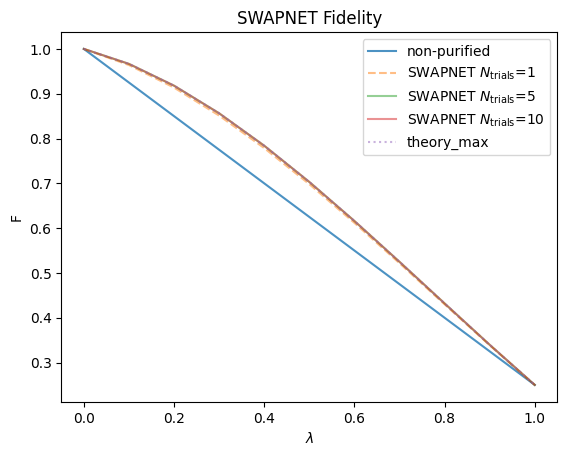

In [47]:
plt.plot(list_of_Lambda,list_of_unpurified_fidelity,label='non-purified', alpha=0.8)
# plt.plot(list_of_epsilon,list_of_purified_fidelity_swap,label='swap-test12', alpha=0.8, linestyle='dashed')

plt.plot(list_of_Lambda,list_of_purified_fidelity_n1,label='SWAPNET $N_{\mathrm{trials}}$='+str(1), alpha=0.5, linestyle='dashed')
plt.plot(list_of_Lambda,list_of_purified_fidelity_n5,label='SWAPNET $N_{\mathrm{trials}}$='+str(5), alpha=0.5)
plt.plot(list_of_Lambda,list_of_purified_fidelity_n10,label='SWAPNET $N_{\mathrm{trials}}$='+str(10), alpha=0.5)
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0,label='SWAPNET12-13 flag=0 n='+str(10), alpha=0.5, linestyle='dashed')
plt.plot(list_of_Lambda,list_of_purified_fidelity_theory,label='theory_max', alpha=0.5, linestyle='dotted')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1_n1,label='SWAPNET12-13 flag=1 n='+str(1), alpha=0.8, linestyle='dashed')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1,label='SWAPNET12-13 flag=1 n='+str(10), alpha=0.8)


    
plt.title("SWAPNET Fidelity")
plt.xlabel("$\lambda$")
plt.ylabel("F")
plt.legend()

In [ ]:
#Simultation code with postselection
list_of_Lambda=[i * 0.1 for i in range(11)]

list_of_purified_fidelity_swap=[]
for Lambda in list_of_Lambda:
    list_of_purified_fidelity_swap.append(state_fidelity(getRhoPrimeWithSWAPTest(Lambda), pure_state))

rows, cols = 2, 0
value = 0
list_of_purified_fidelity= [[value] * cols for _ in range(rows)]
list_of_unpurified_fidelity=[]
list_of_purified_fidelity_theory=[]
for Lambda in list_of_Lambda:
    for N_Trot in range(rows):
        list_of_purified_fidelity[N_Trot].append(state_fidelity(getRhoPrimeWithSWAPNET(Lambda,10**N_Trot,1), pure_state))
    list_of_unpurified_fidelity.append(state_fidelity(getInputRho(Lambda,1,1,1,10), pure_state))
    list_of_purified_fidelity_theory.append(1/8*(-2+Lambda)*(1+Lambda)*(-4+3*Lambda))


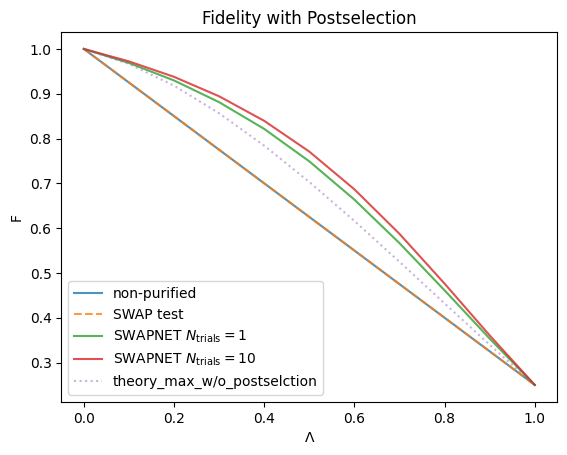

In [42]:
plt.plot(list_of_Lambda,list_of_unpurified_fidelity,label='non-purified', alpha=0.8)
plt.plot(list_of_Lambda,list_of_purified_fidelity_swap,label='SWAP test', alpha=0.8, linestyle='dashed')
for Lambda in range(rows):
    plt.plot(list_of_Lambda,list_of_purified_fidelity[Lambda],label=r'SWAPNET $N_{\mathrm{trials}} = {}$'+str(10**Lambda), alpha=0.8)
plt.plot(list_of_Lambda,list_of_purified_fidelity_theory,label='theory_max_w/o_postselction', alpha=0.5, linestyle='dotted')
plt.title("Fidelity with Postselection")
plt.xlabel("$\Lambda$")
plt.ylabel("F")
plt.legend()

## SWAPNET with GHZ ancilla resource

We see agreement with the original circuit without GHZ

In [44]:
def getRhoPrimeWithSWAPNETGHZ(Lambda,n,post_selection):

    J=1
    h=1 
    t=1
    N_Trot=10

    list_rho_odd=[]
    list_rho_even=[]
    list_p00or11_odd=[]
    list_p00or11_even=[]
    list_p01or10_odd=[]
    list_p01or10_even=[]

    qc_odd = QuantumCircuit(8)
    qc_odd.reset(0)
    qc_odd.reset(1)
    
    # Apply the Hadamard gate to the first and second qubits
    qc_odd.h(0)
    qc_odd.cx(0,1)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_odd.cswap(0, 2, 4)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_odd.cswap(1, 3, 5)
    
    # Apply the second Hadamard gate to the first and second qubits
    qc_odd.h(0)
    qc_odd.h(1)

    
    qc_even = QuantumCircuit(8)
    qc_even.reset(0)
    qc_even.reset(1)
    # Apply the Hadamard gate to the first and second qubits
    qc_even.h(0)
    qc_even.cx(0,1)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_even.cswap(0, 2, 6)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_even.cswap(1, 3, 7)
    
    # Apply the second Hadamard gate to the first and second qubit
    qc_even.h(0)
    qc_even.h(1)


    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(8)
    
    qc=tfimCircuitWithNoiseAtEnd(qc, 2, 3, J, h, t, N_Trot, Lambda)
    qc=tfimCircuitWithNoiseAtEnd(qc, 4, 5, J, h, t, N_Trot, Lambda)
    qc=tfimCircuitWithNoiseAtEnd(qc, 6, 7, J, h, t, N_Trot, Lambda)
    
    # Apply the Hadamard gate to the first and second qubits
    qc.h(0)
    qc.cx(0,1)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 2, 4)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(1, 3, 5)
    
    # Apply the second Hadamard gate to the first and second qubits
    qc.h(0)
    qc.h(1)
    
    state = DensityMatrix(qc)

    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    
    # Create the 8-qubit projection operator using tensor products
    projection_operator00 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P0))
    projection_operator01 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P0))
    projection_operator10 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P1))
    projection_operator11 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P1))
    
    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00
    
    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11

    list_p00or11_odd.append(prob_00+prob_11)
    list_p01or10_odd.append(prob_10+prob_01)
    
    # Trace out qubits q0, q1, q2, q3, q4 and q5
    list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))
    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
    
    state=state.evolve(qc_even)
    
    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00
    
    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11


    list_p00or11_even.append(prob_00+prob_11)
    list_p01or10_even.append(prob_10+prob_01)
    
    
    # Trace out qubits q0, q1, q2, q3, q6, and q7
    list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))
    
    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
    
    for i in range(n-1):
            # Block A
            
            state=state.evolve(qc_odd)
        
            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00
    
            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01
        
            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10
        
            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11
        
            list_p00or11_odd.append(prob_00+prob_11)
            list_p01or10_odd.append(prob_10+prob_01)
            
            # Trace out qubits q0, q1, q2, q3, q4 and q5
            list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))
            
            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))

            # Block B
            state=state.evolve(qc_even)
        
            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00
            
            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01
        
            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10
        
            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11
        
        
        
            list_p00or11_even.append(prob_00+prob_11)
            list_p01or10_even.append(prob_10+prob_01)
            
            
            # Trace out qubits q0, q1, q2, q3, q6, and q7
            list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))
        
            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
        

    
    # Trace out qubits q0, q3, q4, q5, and q6
    #list_rho.append(partial_trace(DensityMatrix(state), [0, 3, 4, 5, 6]))

    purified_rho=list_p01or10_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p00or11_odd[0]*list_p01or10_even[0]*list_rho_even[0]
    
    for j in range(n-1):
        #print(j)
        product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:j+1])
        product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:j+1])
        product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

        purified_rho=purified_rho+product_list_p00or11*list_p01or10_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p00or11*list_p00or11_odd[j+1]*list_p01or10_even[j+1]*list_rho_even[j+1]

    product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:n])
    product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:n])
    product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

    if post_selection > 0:
        # purified_rho=partial_trace(state, [0, 1, 2, 3, 4])
        # purified_rho=partial_trace(state, [0, 1, 2, 5, 6])
        purified_rho=partial_trace(state, [0, 1, 4, 5, 6, 7])
    else:
        purified_rho=purified_rho+product_list_p00or11*partial_trace(state, [0, 1, 2, 3, 4, 5])
        #purified_rho=purified_rho+product_list_p0*maximally_mixed_state


    return DensityMatrix(purified_rho)

In [49]:
list_of_purified_fidelity_flag0_10=[]
list_of_purified_fidelity_flag1=[]
list_of_purified_fidelity_n1=[]
list_of_purified_fidelity_n1_GHZ=[]
list_of_purified_fidelity_flag1_n1=[]
list_of_purified_fidelity_flag0_n5=[]
list_of_purified_fidelity_flag1_n5=[]

list_of_purified_fidelity_theory=[]

for Lambda in list_of_Lambda:
    list_of_purified_fidelity_n1.append(state_fidelity(getRhoPrimeWithSWAPNET(Lambda,1), pure_state))
    list_of_purified_fidelity_n1_GHZ.append(state_fidelity(getRhoPrimeWithSWAPNETGHZ(Lambda,1,0), pure_state))
    # list_of_purified_fidelity_flag1_n1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,1,1), pure_state))
    # list_of_purified_fidelity_flag0_n5.append(state_fidelity(getRhoPrimeWithSWAPNETGHZ(Lambda,5,0), pure_state))
    # list_of_purified_fidelity_flag1_n5.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,5,1), pure_state))
    # list_of_purified_fidelity_flag0_10.append(state_fidelity(getRhoPrimeWithSWAPNETGHZ(Lambda,10,0), pure_state))
    # list_of_purified_fidelity_flag1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,10,1), pure_state))
    list_of_purified_fidelity_theory.append(1/8*(-2+Lambda)*(1+Lambda)*(-4+3*Lambda))


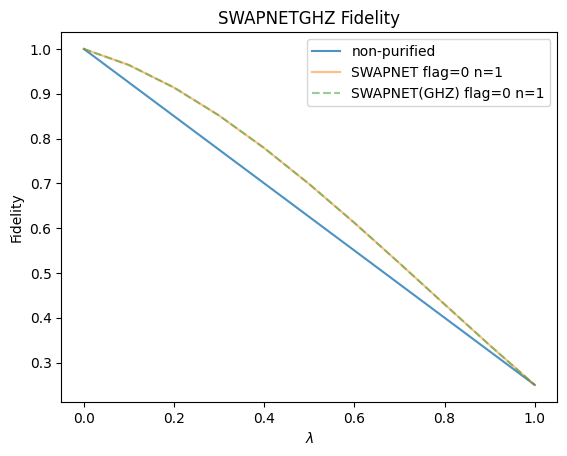

In [ ]:
plt.plot(list_of_epsilon,list_of_unpurified_fidelity,label='non-purified', alpha=0.8)
# plt.plot(list_of_epsilon,list_of_purified_fidelity_swap,label='swap-test12', alpha=0.8, linestyle='dashed')

plt.plot(list_of_epsilon,list_of_purified_fidelity_n1,label='SWAPNET flag=0 n='+str(1), alpha=0.5)
plt.plot(list_of_epsilon,list_of_purified_fidelity_n1_GHZ,label='SWAPNET(GHZ) flag=0 n='+str(1), alpha=0.5, linestyle='dashed')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n5,label='SWAPNET12-13 flag=0 n='+str(5), alpha=0.5)
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0,label='SWAPNET12-13 flag=0 n='+str(10), alpha=0.5, linestyle='dashed')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_theory,label='theory_max', alpha=0.5, linestyle='dotted')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1_n1,label='SWAPNET12-13 flag=1 n='+str(1), alpha=0.8, linestyle='dashed')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1,label='SWAPNET12-13 flag=1 n='+str(10), alpha=0.8)


    
plt.title("SWAPNETGHZ Fidelity")
plt.xlabel("$\epsilon$")
plt.ylabel("Fidelity")
plt.legend()

# Benchmarking the Noisy Case

We add gate-level noise to the circuit (without GHZ) and benchmark the fidelity

In [8]:
def getRhoPrimeWithNoisySWAPTest(t, J, h, N_Trot, epsilon):

    depolarizing = depolarizing_error(epsilon, 1)
    #two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    three_qubit_depolarizing = depolarizing_error(epsilon, 3)
    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(5)

    qc=tfimCircuitWithGateNoise(qc, 1, 2, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 3, 4, J, h, t, N_Trot, epsilon)
        
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    qc.append(depolarizing, [0])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 1, 3)
    qc.append(three_qubit_depolarizing, [0,1,3])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(0, 2, 4)
    qc.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    qc.append(depolarizing, [0])
    
    state = DensityMatrix(qc)

    # Trace out all qubits except q0 to get the reduced density matrix for q0
    # output_rho _q0 = partial_trace(state, [1, 2, 3, 4])
    
    # # Extract probabilities from the reduced density matrix of q0
    # prob_0 = output_rho _q0.data[0, 0].real  # Probability of q0 being in |0>
    # prob_1 = output_rho _q0.data[1, 1].real  # Probability of q0 being in |1>

    # Create the 5-qubit projection operator using tensor products

      # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0))
    projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1))


    #outcome0
    rho_outcome_0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    normalized_rho_outcome_0=rho_outcome_0/prob_0

    #outcome1
    rho_outcome_1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    normalized_rho_outcome_1=rho_outcome_1/prob_1

    # Trace out qubits q0, q3, and q4
    output_rho0 = partial_trace(DensityMatrix(normalized_rho_outcome_0), [0, 1, 2])
    output_rho1 = partial_trace(DensityMatrix(normalized_rho_outcome_1), [0, 1, 2])

    purified_rho=prob_0*output_rho0  + prob_1*output_rho1 #for both outcomes, trace out one reg, therefore the overall state should be as if the purification is not done

    return purified_rho

In [9]:
def getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot, N_trials, post_selection, epsilon):

    list_rho_odd=[]
    list_rho_even=[]
    list_p0_odd=[]
    list_p0_even=[]
    list_p1_odd=[]
    list_p1_even=[]

    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    three_qubit_depolarizing = depolarizing_error(epsilon, 3)

    qc_odd = QuantumCircuit(7)
    qc_odd.reset(0)
    # Apply the Hadamard gate to the first qubit
    qc_odd.h(0)
    qc_odd.append(depolarizing, [0])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_odd.cswap(0, 1, 3)
    qc_odd.append(three_qubit_depolarizing, [0,1,3])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_odd.cswap(0, 2, 4)
    qc_odd.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second Hadamard gate to the first qubit
    qc_odd.h(0)
    qc_odd.append(depolarizing, [0])

    
    qc_even = QuantumCircuit(7)
    qc_even.reset(0)
    # Apply the Hadamard gate to the first qubit
    qc_even.h(0)
    qc_even.append(depolarizing, [0])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_even.cswap(0, 1, 5)
    qc_even.append(three_qubit_depolarizing, [0,1,5])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_even.cswap(0, 2, 6)
    qc_even.append(three_qubit_depolarizing, [0,2,6])
    
    # Apply the second Hadamard gate to the first qubit
    qc_even.h(0)
    qc_even.append(depolarizing, [0])


    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(7)

    qc=tfimCircuitWithGateNoise(qc, 1, 2, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 3, 4, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 5, 6, J, h, t, N_Trot, epsilon)    
    
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    qc.append(depolarizing, [0])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 1, 3)
    qc.append(three_qubit_depolarizing, [0,1,3])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(0, 2, 4)
    qc.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    qc.append(depolarizing, [0])
    
    state = DensityMatrix(qc)


    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    
    # Create the 7-qubit projection operator using tensor products
    projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0))
    projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1))
    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    # print(post_meas_rho0)
    list_p0_odd.append(prob_0)
    
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    # print(post_meas_rho1)
    list_p1_odd.append(prob_1)
    
    # Trace out qubits q0, q1, q2, q3, and q4
    list_rho_odd.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 3, 4]))

    # update the state
    state=DensityMatrix(post_meas_rho0)
    # print(state)

    state=state.evolve(qc_even)
    # print(state)
    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    # print(projected_rho0)
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    # print(post_meas_rho0)
    list_p0_even.append(prob_0)
            
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    # print(projected_rho1)
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    # print(post_meas_rho1)
    list_p1_even.append(prob_1)
    
    # Trace out qubits q0, q1, q2, q5, and q6
    list_rho_even.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 5, 6]))

    # update the state
    state=DensityMatrix(post_meas_rho0)

    
    for i in range(N_trials-1):
            # Block A
            
            state=state.evolve(qc_odd)
            
            projected_rho0=projection_operator0@state@projection_operator0.adjoint()
            prob_0=np.trace(projection_operator0@state@projection_operator0)
            post_meas_rho0=projected_rho0/prob_0
            list_p0_odd.append(prob_0)
            
            projected_rho1=projection_operator1@state@projection_operator1.adjoint()
            prob_1=np.trace(projection_operator1@state@projection_operator1)
            post_meas_rho1=projected_rho1/prob_1
            list_p1_odd.append(prob_1)
            
            # Trace out qubits q0, q1, q2, q3, and q4
            list_rho_odd.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 3, 4]))
        
            # update the state
            state=DensityMatrix(post_meas_rho0)


            # Block B
            state=state.evolve(qc_even)
    
            projected_rho0=projection_operator0@state@projection_operator0.adjoint()
            prob_0=np.trace(projection_operator0@state@projection_operator0)
            post_meas_rho0=projected_rho0/prob_0
            list_p0_even.append(prob_0)
            
            projected_rho1=projection_operator1@state@projection_operator1.adjoint()
            prob_1=np.trace(projection_operator1@state@projection_operator1)
            post_meas_rho1=projected_rho1/prob_1
            list_p1_even.append(prob_1)
            
            # Trace out qubits q0, q1, q2, q5, and q6
            list_rho_even.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 5, 6]))
        
            # update the state
            state=DensityMatrix(post_meas_rho0)


    

    # Trace out qubits q0, q3, q4, q5, and q6
    #list_rho.append(partial_trace(DensityMatrix(state), [0, 3, 4, 5, 6]))

    
    purified_rho=list_p1_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p0_odd[0]*list_p1_even[0]*list_rho_even[0]
    
    for j in range(N_trials-1):
        #print(j)
        product_list_p0_odd=reduce(lambda x, y: x * y, list_p0_odd[:j+1])
        product_list_p0_even=reduce(lambda x, y: x * y, list_p0_even[:j+1])
        product_list_p0=product_list_p0_odd*product_list_p0_even

        purified_rho=purified_rho+product_list_p0*list_p1_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p0*list_p0_odd[j+1]*list_p1_even[j+1]*list_rho_even[j+1]

    product_list_p0_odd=reduce(lambda x, y: x * y, list_p0_odd[:N_trials])
    product_list_p0_even=reduce(lambda x, y: x * y, list_p0_even[:N_trials])
    product_list_p0=product_list_p0_odd*product_list_p0_even

    if post_selection > 0:
        # purified_rho=partial_trace(state, [0, 1, 2, 3, 4])
        # purified_rho=partial_trace(state, [0, 1, 2, 5, 6])
        purified_rho=partial_trace(state, [0, 3, 4, 5, 6])
    else:
        purified_rho=purified_rho+product_list_p0*partial_trace(state, [0, 1, 2, 3, 4])
        #purified_rho=purified_rho+product_list_p0*maximally_mixed_state


    return DensityMatrix(purified_rho)


Getting some intuition for a fixed $N_\mathrm{Trot}$

In [11]:
list_of_epsilon=[i * 0.01 for i in range(11)]

list_of_unpurified_fidelity=[]
list_of_purified_fidelity_swap_noisy=[]
list_of_purified_fidelity_n1_noisy=[]
list_of_purified_fidelity_n2_noisy=[]
list_of_purified_fidelity_theory=[]

t=1
N_Trot=5
J=1
h=1
pure_state = getExactState(J, h, t)

for epsilon in list_of_epsilon:
    list_of_purified_fidelity_swap_noisy.append(state_fidelity(getRhoPrimeWithNoisySWAPTest(t, J, h, N_Trot, epsilon), pure_state))
    list_of_purified_fidelity_n1_noisy.append(state_fidelity(getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot, 1, 0, epsilon), pure_state))
    list_of_purified_fidelity_n2_noisy.append(state_fidelity(getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot, 3, 0, epsilon), pure_state))
    list_of_unpurified_fidelity.append(state_fidelity(getInputRho(epsilon, J, h, t, N_Trot,1), pure_state))

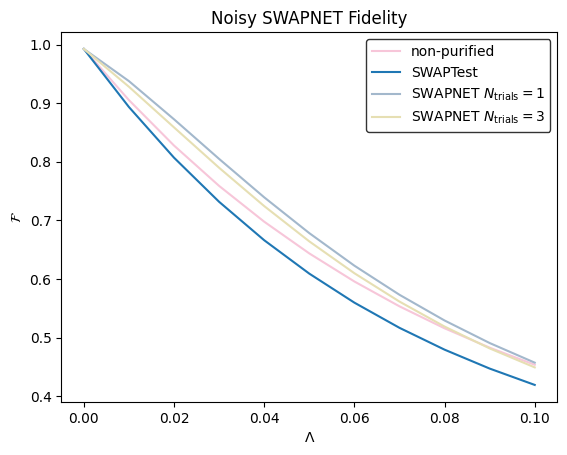

In [12]:
plt.rcParams['text.usetex']=False
# plt.rcParams['font.serif']='Computer Modern'
# plt.rcParams['text.latex.preamble']=r'\usepackage{amsmath}'
plt.plot(list_of_epsilon,list_of_unpurified_fidelity,label='non-purified', color='#F7C6D9')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n1,label='SWAPNET12-13 flag=0 n='+str(1), alpha=0.5, linestyle='dashed')
plt.plot(list_of_epsilon,list_of_purified_fidelity_swap_noisy,label='SWAPTest')
plt.plot(list_of_epsilon,list_of_purified_fidelity_n1_noisy,label='SWAPNET $N_\mathrm{trials}=1$', color = '#A3B8CC')
plt.plot(list_of_epsilon,list_of_purified_fidelity_n2_noisy,label='SWAPNET $N_\mathrm{trials}=3$', color = '#E6DFB3')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_theory,label='theory_max', alpha=0.5, linestyle='dotted')
    
plt.title("Noisy SWAPNET Fidelity")

plt.xlabel("$\\Lambda$")
plt.ylabel("$\\mathcal{F}$")
plt.legend(loc='upper right',edgecolor = 'black')



## Optimizing for $N_{\mathrm{Trot}}$

In [75]:
list_of_epsilon=[i * 0.01 for i in range(11)]
t=1
J=1
h=1
N_Trot_max=5
# list_of_purified_fidelity_flag0_n1=[]
list_of_purified_fidelity_n1_noisy=[[] for _ in range(N_Trot_max)]
list_of_purified_fidelity_n2_noisy=[[] for _ in range(N_Trot_max)]
# list_of_purified_fidelity_flag0_n2_noisy=[]
list_of_unpurified_fidelity=[[] for _ in range(N_Trot_max)]
# list_of_purified_fidelity_theory=[]

pure_state = getExactState(J, h, t)


for N_Trot in range(N_Trot_max):
    for epsilon in list_of_epsilon:
        # list_of_purified_fidelity_flag0_n1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,t,N,1,1), pure_state))
        list_of_purified_fidelity_n1_noisy[N_Trot].append(state_fidelity(getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot+1, 1,0,epsilon), pure_state))
        list_of_purified_fidelity_n2_noisy[N_Trot].append(state_fidelity(getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot+1, 2,0,epsilon), pure_state))
        list_of_unpurified_fidelity[N_Trot].append(state_fidelity(getInputRho(epsilon, J, h, t, N_Trot+1,1), pure_state))

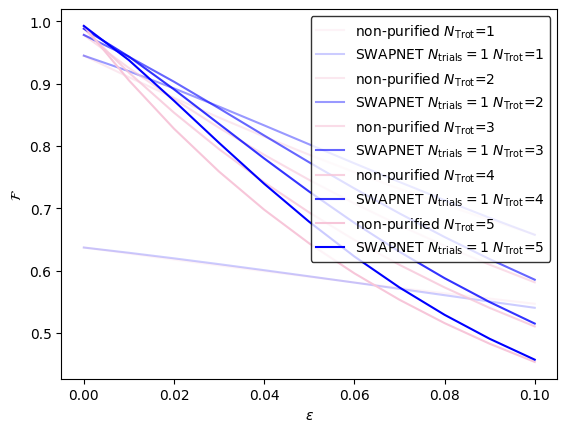

In [76]:
plt.rcParams['text.usetex']=False

for N_Trot in range(N_Trot_max):
    plt.plot(list_of_epsilon,list_of_unpurified_fidelity[N_Trot],label='non-purified'+' $N_\mathrm{Trot}$='+str(N_Trot+1), color='#F7C6D9',alpha=(N_Trot+1)/N_Trot_max)
    plt.plot(list_of_epsilon,list_of_purified_fidelity_n1_noisy[N_Trot],label='SWAPNET $N_\mathrm{trials}=1$'+' $N_\mathrm{Trot}$='+str(N_Trot+1), color = 'b',alpha=(N_Trot+1)/N_Trot_max)
    
plt.xlabel("$\\epsilon$")
plt.ylabel("$\\mathcal{F}$")
plt.legend(loc='upper right',edgecolor = 'black')

Maixmize over all $N_\mathrm{Trot}$

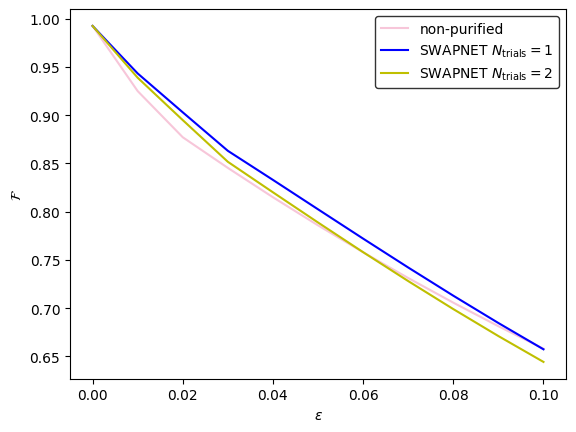

In [78]:
plt.rcParams['text.usetex']=False

max_list_of_fidelity=np.max(np.array(list_of_unpurified_fidelity), axis=0)
max_list_of_purified_fidelity_flag0_n1_noisy=np.max(np.array(list_of_purified_fidelity_n1_noisy), axis=0)
max_list_of_purified_fidelity_flag0_n2_noisy=np.max(np.array(list_of_purified_fidelity_n2_noisy), axis=0)

plt.plot(list_of_epsilon,max_list_of_fidelity,label='non-purified', color='#F7C6D9')
plt.plot(list_of_epsilon,max_list_of_purified_fidelity_flag0_n1_noisy,label='SWAPNET $N_\mathrm{trials}=1$', color = 'b')
plt.plot(list_of_epsilon,max_list_of_purified_fidelity_flag0_n2_noisy,label='SWAPNET $N_\mathrm{trials}=2$', color = 'y')
    
plt.xlabel("$\\epsilon$")
plt.ylabel("$\\mathcal{F}$")
plt.legend(loc='upper right',edgecolor = 'black')

## Noisy SWAPNET-GHZ

In [ ]:
def getRhoPrimeWithNoisySWAPNETGHZ(t, J, h, N_Trot, N_trials, post_select,epsilon):

    list_rho_odd=[]
    list_rho_even=[]
    list_p00or11_odd=[]
    list_p00or11_even=[]
    list_p01or10_odd=[]
    list_p01or10_even=[]

    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    three_qubit_depolarizing = depolarizing_error(epsilon, 3)

    qc_odd = QuantumCircuit(8)
    qc_odd.reset(0)
    qc_odd.reset(1)
    
    # Apply the Hadamard gate to the first and second qubits
    qc_odd.h(0)
    # qc_odd.append(depolarizing, [0])
    qc_odd.cx(0,1)
    qc_odd.append(two_qubit_depolarizing, [0,1])

    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_odd.cswap(0, 2, 4)
    qc_odd.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_odd.cswap(1, 3, 5)
    qc_odd.append(three_qubit_depolarizing, [1,3,5])
    
    # Apply the second Hadamard gate to the first and second qubits
    qc_odd.h(0)
    qc_odd.append(depolarizing, [0])
    
    qc_odd.h(1)
    qc_odd.append(depolarizing, [1])

    
    qc_even = QuantumCircuit(8)
    qc_even.reset(0)
    qc_even.reset(1)
    
    # Apply the Hadamard gate to the first and second qubits
    qc_even.h(0)
    # qc_even.append(depolarizing, [0])
    qc_even.cx(0,1)
    qc_even.append(two_qubit_depolarizing, [0,1])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_even.cswap(0, 2, 6)
    qc_even.append(three_qubit_depolarizing, [0,2,6])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_even.cswap(1, 3, 7)
    qc_even.append(three_qubit_depolarizing, [1,3,7])
    
    # Apply the second Hadamard gate to the first and second qubit
    qc_even.h(0)
    qc_even.append(depolarizing, [0])
    
    qc_even.h(1)
    qc_even.append(depolarizing, [1])


    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(8)

    qc=tfimCircuitWithGateNoise(qc, 2, 3, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 4, 5, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 6, 7, J, h, t, N_Trot, epsilon)

    # Apply the Hadamard gate to the first and second qubits
    qc.h(0)
    # qc.append(depolarizing, [0])
    qc.cx(0,1)
    qc.append(two_qubit_depolarizing, [0,1])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 2, 4)
    qc.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(1, 3, 5)
    qc.append(three_qubit_depolarizing, [1,3,5])
    
    # Apply the second Hadamard gate to the first and second qubits
    qc.h(0)
    qc.append(depolarizing, [0])
    
    qc.h(1)
    qc.append(depolarizing, [1])
    
    state = DensityMatrix(qc)

    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    
    # Create the 8-qubit projection operator using tensor products
    projection_operator00 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P0))
    projection_operator01 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P0))
    projection_operator10 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P1))
    projection_operator11 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P1))
    
    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00
    
    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11

    list_p00or11_odd.append(prob_00+prob_11)
    list_p01or10_odd.append(prob_10+prob_01)
    
    # Trace out qubits q0, q1, q2, q3, q4 and q5
    list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))
    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
    
    state=state.evolve(qc_even)
    
    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00
    
    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11


    list_p00or11_even.append(prob_00+prob_11)
    list_p01or10_even.append(prob_10+prob_01)
    
    
    # Trace out qubits q0, q1, q2, q3, q6, and q7
    list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))
    
    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
    
    for i in range(N_trials-1):
            # Block A
            state=state.evolve(qc_odd)
        
            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00
    
            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01
        
            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10
        
            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11
        
            list_p00or11_odd.append(prob_00+prob_11)
            list_p01or10_odd.append(prob_10+prob_01)
            
            # Trace out qubits q0, q1, q2, q3, q4 and q5
            list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))
            
            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))

            # Block B
            state=state.evolve(qc_even)
        
            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00
            
            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01
        
            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10
        
            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11
        
        
        
            list_p00or11_even.append(prob_00+prob_11)
            list_p01or10_even.append(prob_10+prob_01)
            
            
            # Trace out qubits q0, q1, q2, q3, q6, and q7
            list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))
        
            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
        

    
    # Trace out qubits q0, q3, q4, q5, and q6
    #list_rho.append(partial_trace(DensityMatrix(state), [0, 3, 4, 5, 6]))

    purified_rho=list_p01or10_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p00or11_odd[0]*list_p01or10_even[0]*list_rho_even[0]
    
    for j in range(N_trials-1):
        #print(j)
        product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:j+1])
        product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:j+1])
        product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

        purified_rho=purified_rho+product_list_p00or11*list_p01or10_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p00or11*list_p00or11_odd[j+1]*list_p01or10_even[j+1]*list_rho_even[j+1]

    product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:N_trials])
    product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:N_trials])
    product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

    if post_select > 0:
        # purified_rho=partial_trace(state, [0, 1, 2, 3, 4])
        # purified_rho=partial_trace(state, [0, 1, 2, 5, 6])
        purified_rho=partial_trace(state, [0, 1, 4, 5, 6, 7])
    else:
        purified_rho=purified_rho+product_list_p00or11*partial_trace(state, [0, 1, 2, 3, 4, 5])
        #purified_rho=purified_rho+product_list_p0*maximally_mixed_state


    return DensityMatrix(purified_rho) 

### Getting some intuition for a fixed Trot number

In [23]:
#let's take 
list_of_epsilon=[i * 0.01 for i in range(11)]

list_of_purified_fidelity_n1=[]
list_of_purified_fidelity_n1_noisy_GHZ=[]
list_of_purified_fidelity_n2_noisy_GHZ=[]
list_of_purified_fidelity_theory=[]

t=1
N_Trot=5

pure_state = getExactState(J, h, t)

for epsilon in list_of_epsilon:
    # list_of_purified_fidelity_flag0_n1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,t,N,1,1), pure_state))
    # list_of_unpurified_fidelity.append(state_fidelity(getInputRho(epsilon, J, h, t, N_Trot,1), pure_state))
    list_of_purified_fidelity_n1_noisy_GHZ.append(state_fidelity(getRhoPrimeWithNoisySWAPNETGHZ(t, J, h, N_Trot, 1, 0, epsilon), pure_state))
    list_of_purified_fidelity_n2_noisy_GHZ.append(state_fidelity(getRhoPrimeWithNoisySWAPNETGHZ(t, J, h, N_Trot, 2, 0, epsilon), pure_state))

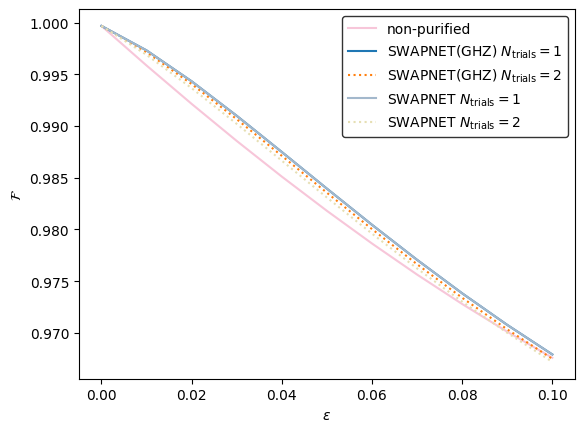

In [ ]:
plt.rcParams['text.usetex']=False
# plt.rcParams['font.serif']='Computer Modern'
# plt.rcParams['text.latex.preamble']=r'\usepackage{amsmath}'
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_unpurified_fidelity],label='non-purified', color='#F7C6D9')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n1,label='SWAPNET12-13 flag=0 n='+str(1), alpha=0.5, linestyle='dashed')
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_purified_fidelity_n1_noisy_GHZ],label='SWAPNET(GHZ) $N_\mathrm{trials}=1$')
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_purified_fidelity_n2_noisy_GHZ],label='SWAPNET(GHZ) $N_\mathrm{trials}=2$', linestyle='dotted')
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_purified_fidelity_n1_noisy],label='SWAPNET $N_\mathrm{trials}=1$', color = '#A3B8CC')
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_purified_fidelity_n2_noisy],label='SWAPNET $N_\mathrm{trials}=2$', color = '#E6DFB3', linestyle='dotted')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_theory,label='theory_max', alpha=0.5, linestyle='dotted')


plt.xlabel("$\\epsilon$")
plt.ylabel("$\\mathcal{F}$")
plt.legend(loc='upper right',edgecolor = 'black')